In [ ]:
!pip install datasets transformers torch torchvision pillow scikit-learn tqdm

from datasets import load_from_disk
from PIL import ImageFile
from tqdm import tqdm
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/facebook_memes_full/train"
dataset = load_from_disk(dataset_path)

print(f"Dataset loaded! Total rows: {len(dataset)}")

Mounted at /content/drive


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Dataset loaded! Total rows: 235880


In [ ]:
# Prevent crashes from corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Extract only reactions (VERY IMPORTANT for speed)
all_reactions = dataset['reactions']

In [ ]:
import ast  #  needed to convert string → list

reaction_types = set()

for reactions in tqdm(all_reactions, desc="Finding reaction types"):
    if not reactions:
        continue

    #  FIX: convert string → list
    try:
        reactions = ast.literal_eval(reactions)
    except:
        continue

    for r in reactions:
        try:
            name = r.split(':')[0].strip()
            reaction_types.add(name)
        except:
            continue

print("Reaction types found:", reaction_types)

Finding reaction types: 100%|██████████| 235880/235880 [00:26<00:00, 9069.14it/s] 

Reaction types found: {'Haha', 'Love', 'Sad', 'Angry', 'Wow', 'Care', 'Like'}


In [ ]:
ALL_REACTIONS = ['Like', 'Love', 'Haha', 'Wow', 'Sad', 'Angry', 'Care']

In [ ]:
def parse_reactions(reaction_list):
    vec = {r: 0 for r in ALL_REACTIONS}

    if not reaction_list:
        return [0] * len(ALL_REACTIONS)

    #  convert string → list
    try:
        reaction_list = ast.literal_eval(reaction_list)
    except:
        return [0] * len(ALL_REACTIONS)

    for item in reaction_list:
        try:
            name = item.split(':')[0].strip()
            count = int(item.split(':')[1].strip().split()[0])

            if name in vec:
                vec[name] = count
        except:
            continue

    return [vec[r] for r in ALL_REACTIONS]

In [ ]:
print(dataset)
print(dataset[0])

sample = dataset[0]
vec = parse_reactions(sample['reactions'])
print("Parsed vector:", vec)

Dataset({
    features: ['image', 'id', 'user_id', 'date', 'likes', 'shares', 'comments', 'post_text', 'post_link', 'img_link', 'ocr', 'caption', 'reactions'],
    num_rows: 235880
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x582 at 0x797F2815AC00>, 'id': '1464012967093033_added-338', 'user_id': 598646039.0, 'date': '2022-01-28 23:20:08', 'likes': 21.0, 'shares': 2, 'comments': 0, 'post_text': 'Socialist Meme Caucus\nJanuary 26, 2020 at 5:42 AM ·', 'post_link': 'https://m.facebook.com/groups/1464012967093033/permalink/2046480045512986/', 'img_link': 'https://scontent.fbud10-1.fna.fbcdn.net/v/t1.6435-9/83045983_2619798538136508_2131958737089331200_n.jpg?_nc_cat=103&ccb=1-7&_nc_sid=dd63ad&_nc_ohc=-GPF-bNX4ZgAX-NhJxB&_nc_oc=AQnHilWjjlC3UtGZYXX3kSnuM6-rchHCGZVSYrEcSMQn8iXB3LjmGAAF8o3HkieuKzw&_nc_ht=scontent.fbud10-1.fna&oh=00_AfBRRgViA-68PFwhTNysgJQ1Ud7OGcdaF72Pc2vMDsrIqw&oe=65633A5D', 'ocr': 'humans area cancer to tinie eartr overpopulation tragedyof the commons

In [ ]:
import numpy as np

def to_prob(vec):
    vec = np.array(vec, dtype=float)
    total = vec.sum() + 1e-9
    return vec / total

In [ ]:
def entropy(p):
    return -np.sum(p * np.log2(p + 1e-9))


In [ ]:
from tqdm import tqdm

entropy_values = []
valid_indices = []

all_reactions = dataset['reactions']

for i, reactions in enumerate(tqdm(all_reactions, desc="Calculating Social Entropy")):

    if not reactions:
        reactions = []

    # ❌ DO NOT use ast here anymore

    vec = parse_reactions(reactions)
    total_reactions = sum(vec)

    if total_reactions < 10:
        continue

    p = to_prob(vec)
    H = entropy(p)

    entropy_values.append(H)
    valid_indices.append(i)

print(f"\n✅ Done. Total valid samples kept: {len(entropy_values)} out of {len(dataset)}")

Calculating Social Entropy: 100%|██████████| 235880/235880 [00:33<00:00, 7098.32it/s] 


✅ Done. Total valid samples kept: 185766 out of 235880


✅ Randomly Selected: Post #209364
   Total reactions: 19
   Non-zero categories: 2
   Counts (Like/Love/Haha/Wow/Sad/Angry/Care): [11, 0, 8, 0, 0, 0, 0]

 SHANNON ENTROPY CALCULATION — Post #209364
╒═════╤══════════════════╤═════════╤══════════╤═══════════════╤═══════════════════════╕
│ i   │ x_i (Reaction)   │   Count │   P(x_i) │ log₂ P(x_i)   │ -P(x_i)·log₂ P(x_i)   │
╞═════╪══════════════════╪═════════╪══════════╪═══════════════╪═══════════════════════╡
│ 1   │ Like             │      11 │   0.5789 │ -0.7885       │ 0.4565                │
├─────┼──────────────────┼─────────┼──────────┼───────────────┼───────────────────────┤
│ 2   │ Love             │       0 │        0 │ —             │ 0.0000                │
├─────┼──────────────────┼─────────┼──────────┼───────────────┼───────────────────────┤
│ 3   │ Haha             │       8 │   0.4211 │ -1.2479       │ 0.5254                │
├─────┼──────────────────┼─────────┼──────────┼───────────────┼───────────────────────┤
│ 4   │ Wo

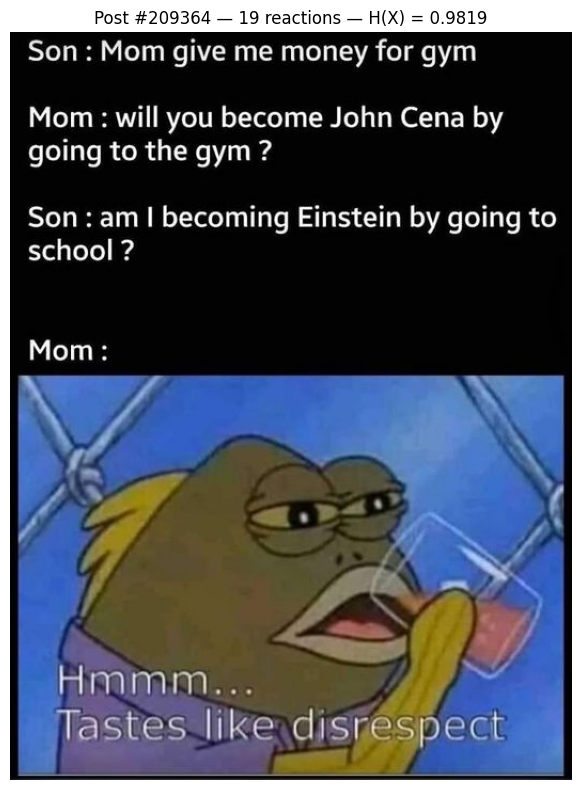

   Saved: example_post_209364.png


In [ ]:
!pip install tabulate -q

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from tabulate import tabulate


chosen_idx = random.choice(valid_indices)

# Get the reactions and parse
reactions_str = all_reactions[chosen_idx]
vec = parse_reactions(reactions_str)
total = sum(vec)
non_zero = sum(1 for c in vec if c > 0)

print(f"✅ Randomly Selected: Post #{chosen_idx}")
print(f"   Total reactions: {total:,}")
print(f"   Non-zero categories: {non_zero}")
print(f"   Counts (Like/Love/Haha/Wow/Sad/Angry/Care): {vec}\n")

counts = np.array(vec, dtype=float)
probs = counts / counts.sum()

log_probs = np.zeros_like(probs)
contribs = np.zeros_like(probs)
for j in range(len(probs)):
    if probs[j] > 0:
        log_probs[j] = np.log2(probs[j])
        contribs[j] = -probs[j] * log_probs[j]

# Build rows for the table
table_data = []
for j, name in enumerate(ALL_REACTIONS):
    table_data.append([
        j + 1,
        name,
        int(counts[j]),
        f"{probs[j]:.4f}",
        f"{log_probs[j]:.4f}" if probs[j] > 0 else "—",
        f"{contribs[j]:.4f}",
    ])

H = float(contribs.sum())
table_data.append([
    "—",
    "TOTAL",
    int(total),
    "1.0000",
    "—",
    f"H(X) = {H:.4f}",
])

headers = ["i", "x_i (Reaction)", "Count", "P(x_i)", "log₂ P(x_i)", "-P(x_i)·log₂ P(x_i)"]


print("=" * 90)
print(f" SHANNON ENTROPY CALCULATION — Post #{chosen_idx}")
print("=" * 90)
print(tabulate(table_data, headers=headers, tablefmt="fancy_grid",
               numalign="right", stralign="left"))
print(f"\n Shannon Entropy H(X) = {H:.4f}")
print(f"   Maximum theoretical entropy log₂(7) = {np.log2(7):.4f}")


print("\n" + "=" * 90)
print(f" POST DETAILS — Post #{chosen_idx}")
print("=" * 90)

sample = dataset[chosen_idx]
for field in sample.keys():
    if field == "image":
        continue
    value = sample[field]
    if isinstance(value, str) and len(value) > 300:
        print(f"{field}: {value[:300]}...")
    else:
        print(f"{field}: {value}")


if "image" in sample and sample["image"] is not None:
    print("\n POST IMAGE:")
    plt.figure(figsize=(8, 8))
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.title(f"Post #{chosen_idx} — {total:,} reactions — H(X) = {H:.4f}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"example_post_{chosen_idx}.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"   Saved: example_post_{chosen_idx}.png")

In [ ]:
# from matplotlib.ticker import FuncFormatter
# import matplotlib.pyplot as plt

# # ============================================================
# # BETTER PUBLICATION-QUALITY BAR GRAPH
# # ============================================================

# plt.figure(figsize=(12,6))

# colors = [
#     "#1877F2",   # Like
#     "#F02849",   # Love
#     "#F7B125",   # Haha
#     "#F7B125",   # Wow
#     "#7B8894",   # Sad
#     "#E9710F",   # Angry
#     "#42B72A"    # Care
# ]

# bars = plt.bar(
#     ALL_REACTIONS,
#     reaction_totals,
#     color=colors,
#     edgecolor="black",
#     linewidth=1.2
# )

# # --------------------------------------------------
# # Numbers above bars (HORIZONTAL)
# # --------------------------------------------------

# for bar, value in zip(bars, reaction_totals):

#     plt.text(
#         bar.get_x() + bar.get_width()/2,
#         value + grand_total*0.002,
#         f"{value:,}",
#         ha="center",
#         va="bottom",
#         fontsize=10,
#         fontweight="bold",
#         rotation=0          # Horizontal
#     )

# # --------------------------------------------------
# # Format Y-axis in Millions
# # --------------------------------------------------

# def millions(x, pos):
#     return f"{x/1_000_000:.0f} M"

# plt.gca().yaxis.set_major_formatter(
#     FuncFormatter(millions)
# )

# # --------------------------------------------------
# # Labels
# # --------------------------------------------------

# plt.title(
#     "Overall Facebook Reaction Distribution",
#     fontsize=16,
#     fontweight="bold"
# )

# plt.xlabel(
#     "Facebook Reactions",
#     fontsize=13
# )

# plt.ylabel(
#     "Total Reaction Count (Millions)",
#     fontsize=13
# )

# plt.grid(
#     axis="y",
#     linestyle="--",
#     alpha=0.35
# )

# plt.tight_layout()

# plt.savefig(
#     "/content/drive/MyDrive/facebook_reaction_distribution_improved.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from openpyxl import Workbook
# from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
# from openpyxl.utils import get_column_letter

# entropy_lookup = dict(zip(valid_indices, entropy_values))

# PREVIEW_LIMIT = len(valid_indices)

# print(f"Building preview with {PREVIEW_LIMIT} rows...")

# records = []
# for i in tqdm(valid_indices[:PREVIEW_LIMIT], desc="Processing", unit="post"):
#     sample = dataset[i]
#     reactions_str = all_reactions[i]
#     vec = parse_reactions(reactions_str)
#     counts = np.array(vec, dtype=float)
#     total = counts.sum()
#     if total == 0:
#         continue

#     probs = counts / total
#     log_probs = np.where(probs > 0, np.log2(probs + 1e-30), 0)
#     contribs = -probs * log_probs

#     row = [
#         i,
#         sample.get("date", ""),
#         (sample.get("post_text", "") or "")[:200],
#         (sample.get("ocr", "") or "")[:200],
#         sample.get("img_link", ""),
#         sample.get("post_link", ""),
#     ]
#     for j in range(len(ALL_REACTIONS)):
#         row.append(int(counts[j]))
#         row.append(round(float(probs[j]), 4))
#         row.append(round(float(log_probs[j]), 4) if probs[j] > 0 else 0)
#         row.append(round(float(contribs[j]), 4))
#     row.append(round(entropy_lookup[i], 4))
#     records.append(row)

# output_path = "/content/drive/MyDrive/social_encoder_186k_full_entropy.xlsx"

# wb = Workbook()
# ws = wb.active
# ws.title = "Preview"

# ws.print_options.horizontalCentered = True
# ws.page_setup.fitToWidth = 1
# ws.page_setup.fitToHeight = 0
# ws.sheet_properties.pageSetUpPr.fitToPage = True
# ws.page_setup.orientation = ws.ORIENTATION_LANDSCAPE

# reaction_colors = {
#     "Like":  "DDEBF7",
#     "Love":  "FCE4D6",
#     "Haha":  "FFF2CC",
#     "Wow":   "E2EFDA",
#     "Sad":   "D9E1F2",
#     "Angry": "F8CBAD",
#     "Care":  "E4DFEC",
# }
# result_color = "C6E0B4"

# thin_border = Border(
#     left=Side(style="thin", color="808080"),
#     right=Side(style="thin", color="808080"),
#     top=Side(style="thin", color="808080"),
#     bottom=Side(style="thin", color="808080"),
# )

# header_font = Font(bold=True)
# center_align = Alignment(horizontal="center", vertical="center", wrap_text=True)

# from openpyxl.cell.rich_text import CellRichText, TextBlock
# from openpyxl.cell.text import InlineFont

# normal_font = InlineFont(b=True, sz=11)
# subscript_font = InlineFont(b=True, sz=8, vertAlign="subscript")

# col = 7
# for j, reaction in enumerate(ALL_REACTIONS):
#     ws.merge_cells(start_row=1, start_column=col, end_row=1, end_column=col + 3)

#     rich_text = CellRichText([
#         TextBlock(normal_font, f"i={j+1}  x"),
#         TextBlock(subscript_font, "i"),
#         TextBlock(normal_font, f"={reaction}"),
#     ])

#     cell = ws.cell(row=1, column=col, value=rich_text)
#     cell.fill = PatternFill("solid", fgColor=reaction_colors[reaction])
#     cell.alignment = center_align
#     cell.border = thin_border
#     col += 4

# result_cell = ws.cell(row=1, column=col, value="Result")
# result_cell.fill = PatternFill("solid", fgColor=result_color)
# result_cell.font = header_font
# result_cell.alignment = center_align
# result_cell.border = thin_border

# sub_headers = ["Post Number", "Date", "Post Text", "OCR Text", "Image URL", "Post Link"]
# for reaction in ALL_REACTIONS:
#     sub_headers.extend(["Count", "P(x_i)", "log₂ P(x_i)", "-P(x_i)·log₂ P(x_i)"])
# sub_headers.append("H(X)")

# for idx, header in enumerate(sub_headers, start=1):
#     cell = ws.cell(row=2, column=idx, value=header)
#     cell.font = header_font
#     cell.alignment = center_align
#     cell.border = thin_border

#     if idx <= 6:
#         cell.fill = PatternFill("solid", fgColor="F2F2F2")
#     elif idx == len(sub_headers):
#         cell.fill = PatternFill("solid", fgColor=result_color)
#     else:
#         reaction_idx = (idx - 7) // 4
#         cell.fill = PatternFill("solid", fgColor=reaction_colors[ALL_REACTIONS[reaction_idx]])

# for row_idx, record in enumerate(records, start=3):
#     for col_idx, value in enumerate(record, start=1):
#         ws.cell(row=row_idx, column=col_idx, value=value)

# column_widths = {
#     1: 12,
#     2: 20,
#     3: 30,
#     4: 30,
#     5: 30,
#     6: 30,
# }
# for c in range(7, len(sub_headers)):
#     column_widths[c] = 12
# column_widths[len(sub_headers)] = 10

# for col_num, width in column_widths.items():
#     ws.column_dimensions[get_column_letter(col_num)].width = width

# ws.freeze_panes = "G3"

# wb.save(output_path)

# print(f"\nPreview file saved to: {output_path}")
# print(f"Rows: {len(records)}")
# print(f"Columns: {len(sub_headers)}")
# print(f"\nOpen the file in Excel to verify the formatting.")

In [ ]:
import os
import pickle

PICKLE_PATH = "/content/drive/MyDrive/social_encoder_data.pkl"

if not os.path.exists(PICKLE_PATH):
    print("Building (texts, targets) from dataset...")

    texts_list = []
    targets_list = []

    for i, H in tqdm(zip(valid_indices, entropy_values),
                     total=len(valid_indices),
                     desc="Building pickle"):
        sample = dataset[i]
        combined = (sample.get("post_text", "") or "") + " " + (sample.get("ocr", "") or "")
        combined = combined.strip()

        if combined:
            texts_list.append(combined)
            targets_list.append(H)

    with open(PICKLE_PATH, "wb") as f:
        pickle.dump((texts_list, targets_list), f)

    print(f"✅ Saved {len(texts_list)} samples to {PICKLE_PATH}")
else:
    print(f"✅ Pickle already exists at {PICKLE_PATH}")

Building (texts, targets) from dataset...


Building pickle: 100%|██████████| 185766/185766 [12:03<00:00, 256.69it/s]


✅ Saved 183040 samples to /content/drive/MyDrive/social_encoder_data.pkl


In [ ]:
import pickle

with open("/content/drive/MyDrive/social_encoder_data.pkl", "rb") as f:
    texts, targets = pickle.load(f)

print("Loaded successfully!")
print("Total samples:", len(texts))

Loaded successfully!
Total samples: 183040


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

#  Normalize entropy targets
targets = np.array(targets, dtype=np.float32)

max_entropy = targets.max()

targets = targets / max_entropy

print(f"Targets normalized! Max entropy: {max_entropy:.4f}")

#  DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

class DistilBertSocialDataset(Dataset):

    def __init__(
        self,
        texts,
        targets,
        tokenizer,
        max_len=128
    ):

        self.texts = texts
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])

        target = self.targets[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "target": torch.tensor(
                target,
                dtype=torch.float32
            )
        }

train_texts, val_texts, train_targets, val_targets = train_test_split(
    texts,
    targets,
    test_size=0.2,
    random_state=42
)

train_dataset = DistilBertSocialDataset(
    train_texts,
    train_targets,
    tokenizer
)

val_dataset = DistilBertSocialDataset(
    val_texts,
    val_targets,
    tokenizer
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("✅ DistilBERT DataLoaders Ready!")

Targets normalized! Max entropy: 1.5850


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ DistilBERT DataLoaders Ready!


In [ ]:
# from transformers import AutoModel, AutoTokenizer

# # Download to Colab's local /root/ cache (fast, no Drive I/O)
# temp_model = AutoModel.from_pretrained("distilbert-base-uncased")
# temp_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# print("✅ Downloaded to local cache")

In [ ]:
# # Now save from local to Drive (fast, no re-download)
# temp_model.save_pretrained("/content/drive/MyDrive/distilbert_base_uncased")
# temp_tokenizer.save_pretrained("/content/drive/MyDrive/distilbert_tokenizer")

# print("✅ Saved to Drive")

In [ ]:
import torch.nn as nn
from transformers import AutoModel
import os

class SocialEntropyDistilBERT(nn.Module):

    def __init__(self):
        super().__init__()

        # Load from Drive if available (fast), else from HuggingFace (slow)
        DISTILBERT_PATH = "/content/drive/MyDrive/distilbert_base_uncased"
        if os.path.exists(DISTILBERT_PATH):
            self.distilbert = AutoModel.from_pretrained(DISTILBERT_PATH)
            print("✅ Loaded DistilBERT from Drive")
        else:
            self.distilbert = AutoModel.from_pretrained("distilbert-base-uncased")
            print("✅ Loaded DistilBERT from HuggingFace")

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Mean pooling
        mask = attention_mask.unsqueeze(-1).float()
        social_embedding = (outputs.last_hidden_state * mask).sum(dim=1) \
                           / mask.sum(dim=1).clamp(min=1)

        dropped = self.dropout(social_embedding)
        entropy = self.fc(dropped).squeeze()

        return entropy, social_embedding


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SocialEntropyDistilBERT().to(device)

# Huber Loss
criterion = nn.SmoothL1Loss()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1
)

print(f"✅ DistilBERT model running on {device}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Loaded DistilBERT from Drive
✅ DistilBERT model running on cuda



========== EPOCH 1/8 ==========


Validation: 100%|██████████| 1144/1144 [02:27<00:00,  7.74it/s]



✅ Train Loss: 0.0184
✅ Validation Loss: 0.0167
✅ MSE: 0.0334
✅ MAE: 0.1240
✅ Pearson Correlation: 0.3155
💾 New BEST model saved (Pearson=0.3155)

========== EPOCH 2/8 ==========


Validation: 100%|██████████| 1144/1144 [02:27<00:00,  7.74it/s]



✅ Train Loss: 0.0165
✅ Validation Loss: 0.0162
✅ MSE: 0.0324
✅ MAE: 0.1231
✅ Pearson Correlation: 0.3537
💾 New BEST model saved (Pearson=0.3537)

========== EPOCH 3/8 ==========


Validation: 100%|██████████| 1144/1144 [02:27<00:00,  7.75it/s]



✅ Train Loss: 0.0141
✅ Validation Loss: 0.0170
✅ MSE: 0.0341
✅ MAE: 0.1299
✅ Pearson Correlation: 0.3462
⏳ No Pearson improvement (1/2)

========== EPOCH 4/8 ==========


Validation: 100%|██████████| 1144/1144 [02:27<00:00,  7.75it/s]



✅ Train Loss: 0.0114
✅ Validation Loss: 0.0181
✅ MSE: 0.0362
✅ MAE: 0.1322
✅ Pearson Correlation: 0.3374
⏳ No Pearson improvement (2/2)

⏹ Early stop triggered — Pearson plateaued for 2 epochs.
   Best Pearson achieved: 0.3537

✅ Training complete. Best Pearson = 0.3537


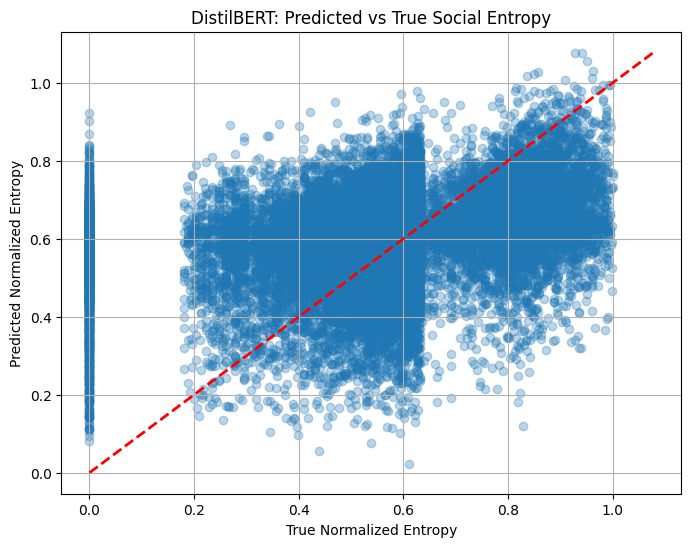

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
from tqdm import tqdm
import torch

#  Up to 8 epochs, but will early-stop if Pearson plateaus
EPOCHS = 8
EARLY_STOP_PATIENCE = 2   # stop if Pearson doesn't improve for N epochs

best_pearson = -1.0
no_improve_count = 0

for epoch in range(EPOCHS):

    print(f"\n========== EPOCH {epoch+1}/{EPOCHS} ==========")

    # =========================================================
    # TRAINING
    # =========================================================

    model.train()

    total_train_loss = 0

    for batch in tqdm(train_loader, desc="Training"):

        #  Move batch to GPU
        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        targets = batch["target"].to(device)

        optimizer.zero_grad()

        # =====================================================
        # FORWARD PASS
        # =====================================================

        # Model returns:
        # 1. entropy prediction
        # 2. 768-D social embedding

        predictions, social_embedding = model(
            input_ids,
            attention_mask
        )

        # =====================================================
        # LOSS
        # =====================================================

        loss = criterion(
            predictions,
            targets
        )

        # =====================================================
        # BACKPROP
        # =====================================================

        loss.backward()

        #  Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # =========================================================
    # VALIDATION
    # =========================================================

    model.eval()

    total_val_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for batch in tqdm(val_loader, desc="Validation"):

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            targets = batch["target"].to(device)

            predictions, social_embedding = model(
                input_ids,
                attention_mask
            )

            loss = criterion(
                predictions,
                targets
            )

            total_val_loss += loss.item()

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

    avg_val_loss = total_val_loss / len(val_loader)
    #  Update learning rate based on validation loss
    scheduler.step(avg_val_loss)

    # =========================================================
    # METRICS
    # =========================================================

    mse = mean_squared_error(
        all_targets,
        all_preds
    )

    mae = mean_absolute_error(
        all_targets,
        all_preds
    )

    corr, _ = pearsonr(
        all_targets,
        all_preds
    )

    print(f"\n✅ Train Loss: {avg_train_loss:.4f}")
    print(f"✅ Validation Loss: {avg_val_loss:.4f}")
    print(f"✅ MSE: {mse:.4f}")
    print(f"✅ MAE: {mae:.4f}")
    print(f"✅ Pearson Correlation: {corr:.4f}")

    # =========================================================
    # SAVE BEST MODEL + EARLY STOP
    # =========================================================

    if corr > best_pearson:

        best_pearson = corr
        no_improve_count = 0   # reset patience counter

        torch.save(
          {
              "model_state_dict": model.state_dict(),
              "max_entropy": max_entropy,
              "pooling": "masked_mean",   # S3 -- tag pooling scheme
              "epoch": epoch + 1,
              "pearson": float(corr),
              "val_loss": float(avg_val_loss),
          },
          "/content/drive/MyDrive/social_encoder_distilbert_best.pt"
        )

        print(f"💾 New BEST model saved (Pearson={corr:.4f})")

    else:
        no_improve_count += 1
        print(f"⏳ No Pearson improvement ({no_improve_count}/{EARLY_STOP_PATIENCE})")

        if no_improve_count >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ Early stop triggered — Pearson plateaued for {no_improve_count} epochs.")
            print(f"   Best Pearson achieved: {best_pearson:.4f}")
            break

print(f"\n✅ Training complete. Best Pearson = {best_pearson:.4f}")

# =============================================================
# FINAL SCATTER PLOT
# =============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    all_targets,
    all_preds,
    alpha=0.3
)

# Perfect prediction line
min_val = min(
    min(all_targets),
    min(all_preds)
)

max_val = max(
    max(all_targets),
    max(all_preds)
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("True Normalized Entropy")
plt.ylabel("Predicted Normalized Entropy")
plt.title("DistilBERT: Predicted vs True Social Entropy")
plt.grid(True)
plt.show()
